# Telecom Customer Churn — Model Training, Inference & Evaluation

- Prepare the feature dataset based on EDA
- Perform ML modeling on the train set with pre-trained Random Forest model  
- Run inference to produce per-customer churn probabilities, and evaluate performance against test set.

---

| Step | Description |
|------|-------------|
| 1 | Environment setup & imports |
| 2 | Data loading & EDA-driven preprocessing |
| 3 | Feature engineering pipeline |
| 4 | Train / test split |
| 5 | Load pre-trained Random Forest model |
| 6 | Inference — churn probability per customer |
| 7 | Threshold tuning |
| 8 | Evaluation report (Accuracy, Precision, Recall, F1, ROC-AUC) |
| 9 | Confusion matrix & visualisations |
| 10 | Feature importance |
| 11 | Export results |


## 1 · Environment Setup

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install Libraries

In [ ]:
# Install / upgrade key libraries
# !pip install -q scikit-learn==1.4.2 pandas numpy matplotlib seaborn joblib imbalanced-learn

## Import and Setup Libraries

In [ ]:
import os, warnings, joblib
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay,
    average_precision_score,
)
from sklearn.pipeline         import Pipeline
from sklearn.impute           import SimpleImputer
from sklearn.compose          import ColumnTransformer
from sklearn.calibration      import calibration_curve
from sklearn.inspection       import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
np.random.seed(SEED)

## 2 · Data Loading


## Define File Paths

In [ ]:
expresso_sample_file = "/path/to/expresso_sample.csv"
telecom_churn_file = "/path/to/telecom_churn.csv"
telecom_churn_100k_file = "/path/to/telecom_churn_100k.csv"
rf_model_file = "/path/to/rf_churn_model.joblib"
expresso_rf_model_file = "/path/to/rf_churn_model.joblib"
churn_predictions_file = "/path/to/churn_predictions.csv"
evaluation_metrics_file = "/path/to/evaluation_metrics.csv"
feature_importances_file = "/path/to/feature_importances.csv"

## Load dataset

In [ ]:
df_raw = pd.read_csv(telecom_churn_100k_file)

In [ ]:
print(f"Loaded from file: {df_raw.shape}")

Loaded from file: (100000, 32)


In [ ]:
print(f"Churn rate: {df_raw['churn'].mean():.1%}")

Churn rate: 18.7%


In [ ]:
df_raw.head()

,user_id,region,tenure,montant,frequence_rech,revenue,arpu_segment,frequence,data_volume,on_net,orange,tigo,zone1,zone2,mrg,regularity,top_pack,freq_top_pack,region_tower_count,region_avg_range,region_avg_samples,region_avg_signal,region_coverage_index,region_signal_strength_index,region_network_quality_score,department_signal_strength_index,department_network_quality_score,department_coverage_index,arr_signal_strength_index,arr_network_quality_score,arr_coverage_index,churn
0,22322777e909ae0aa1c69e7b1fce40f333187fa6,DAKAR,K > 24 month,8650.0000,37.0000,8650.0000,2883.0000,38.0000,2593.0000,3.0000,39.0000,1.0000,NaN,NaN,NO,59,"Data: 100 F=40MB,24H",20.0000,1771.0000,1347.3162,6.2942,0.0000,2386097.0000,0.0000,533.1883,0.0000,134.9141,2386097.0000,0.0000,55.1061,2386097.0000,0
1,453d2b534a53e30171b3c0c72dc7d56415619d8a,NaN,K > 24 month,1000.0000,2.0000,980.0000,327.0000,2.0000,1362.0000,NaN,1.0000,9.0000,NaN,NaN,NO,8,"Data:490F=1GB,7d",2.0000,4.0000,1239.0000,1.7500,0.0000,4956.0000,0.0000,1.7250,0.0000,1.0500,4956.0000,0.0000,1.0500,4956.0000,0
2,9e64b12fd171b51378111bbb1f25242e79c7be99,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,1043.0000,4.0000,NaN,NaN,NaN,NaN,NO,8,NaN,NaN,4.0000,1239.0000,1.7500,0.0000,4956.0000,0.0000,1.7250,0.0000,1.0500,4956.0000,0.0000,1.0500,4956.0000,1
3,369f886e40ef9ec4de23784888d412e5f336cca1,LOUGA,K > 24 month,250.0000,1.0000,250.0000,83.0000,2.0000,389.0000,5.0000,NaN,NaN,NaN,NaN,NO,58,"Data: 200 F=100MB,24H",1.0000,94.0000,4254.2234,3.7766,0.0000,399897.0000,0.0000,29.3330,0.0000,10.5433,399897.0000,0.0000,4.3152,399897.0000,0
4,3524a53cd138dfe31a2f48c2cc21ed4129df1d10,DAKAR,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,7.0000,NaN,NaN,NaN,NaN,NO,15,NaN,NaN,1771.0000,1347.3162,6.2942,0.0000,2386097.0000,0.0000,533.1883,0.0000,134.9141,2386097.0000,0.0000,55.1061,2386097.0000,1


## 3 · Data Preprocessing

Based on the EDA findings:

| Action | Columns |
|--------|---------|
| **DROP** — zero-variance | `mrg`, `region_avg_signal`, `*_signal_strength_index` |
| **DROP** — >90% missing | `zone1`, `zone2` |
| **DROP** — identifier | `user_id` |
| **DROP** — collinear duplicates | `region_coverage_index`, `department_coverage_index` (keep `arr_coverage_index`) |
| **IMPUTE** numerical | median |
| **IMPUTE** categorical | `'Unknown'` |
| **RECODE** tenure | binary: loyal (`K > 24 month`) vs new |
| **ENCODE** region / top_pack | target encoding |


In [ ]:
# Columns to drop
ZERO_VAR = [
    "mrg",
    "region_avg_signal",
    "region_signal_strength_index",
    "department_signal_strength_index",
    "arr_signal_strength_index",
]
COLLINEAR = [
    "arr_coverage_index",
    "department_coverage_index",
    "department_network_quality_score",
]
SPARSE    = [c for c in ["zone1", "zone2"] if c in df_raw.columns]
ID_COLS   = ["user_id"]

DROP_COLS = ZERO_VAR + COLLINEAR + SPARSE + ID_COLS
DROP_COLS = [c for c in DROP_COLS if c in df_raw.columns]

df = df_raw.drop(columns=DROP_COLS).copy()
print(f"Dropped {len(DROP_COLS)} columns → shape: {df.shape}")
print(f"Dropped: {DROP_COLS}")

Dropped 11 columns → shape: (100000, 21)
Dropped: ['mrg', 'region_avg_signal', 'region_signal_strength_index', 'department_signal_strength_index', 'arr_signal_strength_index', 'arr_coverage_index', 'department_coverage_index', 'department_network_quality_score', 'zone1', 'zone2', 'user_id']


## Feature engineering

In [ ]:
# Binary data-user flag (before imputation)
df["is_data_user"]   = (df["data_volume"].fillna(0) > 0).astype(int)
df["no_data_flag"]   = df["data_volume"].isna().astype(int)

In [ ]:
# Avoid division by zero
df["avg_recharge_amount"] = df["montant"]      / (df["frequence_rech"].replace(0, np.nan))
df["avg_revenue_per_tx"]  = df["revenue"]      / (df["frequence"].replace(0, np.nan))
df["network_quality_delta"] = (
    df["region_network_quality_score"] - df["arr_network_quality_score"]
)

In [ ]:
# Log-transform heavy-tailed features
LOG_COLS = ["montant", "revenue", "data_volume", "on_net", "orange", "tigo",
            "freq_top_pack", "avg_recharge_amount", "avg_revenue_per_tx"]
for col in LOG_COLS:
    if col in df.columns:
        df[f"log_{col}"] = np.log1p(df[col].fillna(0).clip(lower=0))

In [ ]:
# Tenure → binary loyal flag
df["is_loyal"] = (df["tenure"] == "K > 24 month").astype(int)
df.drop(columns=["tenure"], inplace=True)

In [ ]:
print(f"After feature engineering → shape: {df.shape}")
df.head()

After feature engineering → shape: (100000, 35)


,region,montant,frequence_rech,revenue,arpu_segment,frequence,data_volume,on_net,orange,tigo,regularity,top_pack,freq_top_pack,region_tower_count,region_avg_range,region_avg_samples,region_coverage_index,region_network_quality_score,arr_network_quality_score,churn,is_data_user,no_data_flag,avg_recharge_amount,avg_revenue_per_tx,network_quality_delta,log_montant,log_revenue,log_data_volume,log_on_net,log_orange,log_tigo,log_freq_top_pack,log_avg_recharge_amount,log_avg_revenue_per_tx,is_loyal
0,DAKAR,8650.0000,37.0000,8650.0000,2883.0000,38.0000,2593.0000,3.0000,39.0000,1.0000,59,"Data: 100 F=40MB,24H",20.0000,1771.0000,1347.3162,6.2942,2386097.0000,533.1883,55.1061,0,1,0,233.7838,227.6316,478.0822,9.0654,9.0654,7.8610,1.3863,3.6889,0.6931,3.0445,5.4587,5.4321,1
1,NaN,1000.0000,2.0000,980.0000,327.0000,2.0000,1362.0000,NaN,1.0000,9.0000,8,"Data:490F=1GB,7d",2.0000,4.0000,1239.0000,1.7500,4956.0000,1.7250,1.0500,0,1,0,500.0000,490.0000,0.6750,6.9088,6.8886,7.2174,0.0000,0.6931,2.3026,1.0986,6.2166,6.1964,1
2,NaN,NaN,NaN,NaN,NaN,NaN,1043.0000,4.0000,NaN,NaN,8,NaN,NaN,4.0000,1239.0000,1.7500,4956.0000,1.7250,1.0500,1,1,0,NaN,NaN,0.6750,0.0000,0.0000,6.9508,1.6094,0.0000,0.0000,0.0000,0.0000,0.0000,1
3,LOUGA,250.0000,1.0000,250.0000,83.0000,2.0000,389.0000,5.0000,NaN,NaN,58,"Data: 200 F=100MB,24H",1.0000,94.0000,4254.2234,3.7766,399897.0000,29.3330,4.3152,0,1,0,250.0000,125.0000,25.0178,5.5255,5.5255,5.9661,1.7918,0.0000,0.0000,0.6931,5.5255,4.8363,1
4,DAKAR,NaN,NaN,NaN,NaN,NaN,NaN,7.0000,NaN,NaN,15,NaN,NaN,1771.0000,1347.3162,6.2942,2386097.0000,533.1883,55.1061,1,0,1,NaN,NaN,478.0822,0.0000,0.0000,0.0000,2.0794,0.0000,0.0000,0.0000,0.0000,0.0000,1


## Define Numerical and Categorical Features

In [ ]:
# Identify column types
TARGET   = "churn"
CAT_COLS = df.select_dtypes(include="object").columns.tolist()
NUM_COLS = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]

print(f"Numerical features : {len(NUM_COLS)}")
print(f"Categorical features: {CAT_COLS}")

Numerical features : 32
Categorical features: ['region', 'top_pack']


In [ ]:
# Target-encode categorical columns
for col in CAT_COLS:
    df[col] = df[col].fillna("Unknown")
    te_map  = df.groupby(col)[TARGET].mean()
    df[col] = df[col].map(te_map).fillna(df[TARGET].mean())

NUM_COLS = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]
print(f"All features now numerical. Total features: {len(NUM_COLS)}")
df.head()

All features now numerical. Total features: 34


,region,montant,frequence_rech,revenue,arpu_segment,frequence,data_volume,on_net,orange,tigo,regularity,top_pack,freq_top_pack,region_tower_count,region_avg_range,region_avg_samples,region_coverage_index,region_network_quality_score,arr_network_quality_score,churn,is_data_user,no_data_flag,avg_recharge_amount,avg_revenue_per_tx,network_quality_delta,log_montant,log_revenue,log_data_volume,log_on_net,log_orange,log_tigo,log_freq_top_pack,log_avg_recharge_amount,log_avg_revenue_per_tx,is_loyal
0,0.0189,8650.0000,37.0000,8650.0000,2883.0000,38.0000,2593.0000,3.0000,39.0000,1.0000,59,0.0458,20.0000,1771.0000,1347.3162,6.2942,2386097.0000,533.1883,55.1061,0,1,0,233.7838,227.6316,478.0822,9.0654,9.0654,7.8610,1.3863,3.6889,0.6931,3.0445,5.4587,5.4321,1
1,0.4478,1000.0000,2.0000,980.0000,327.0000,2.0000,1362.0000,NaN,1.0000,9.0000,8,0.0612,2.0000,4.0000,1239.0000,1.7500,4956.0000,1.7250,1.0500,0,1,0,500.0000,490.0000,0.6750,6.9088,6.8886,7.2174,0.0000,0.6931,2.3026,1.0986,6.2166,6.1964,1
2,0.4478,NaN,NaN,NaN,NaN,NaN,1043.0000,4.0000,NaN,NaN,8,0.3907,NaN,4.0000,1239.0000,1.7500,4956.0000,1.7250,1.0500,1,1,0,NaN,NaN,0.6750,0.0000,0.0000,6.9508,1.6094,0.0000,0.0000,0.0000,0.0000,0.0000,1
3,0.0192,250.0000,1.0000,250.0000,83.0000,2.0000,389.0000,5.0000,NaN,NaN,58,0.0566,1.0000,94.0000,4254.2234,3.7766,399897.0000,29.3330,4.3152,0,1,0,250.0000,125.0000,25.0178,5.5255,5.5255,5.9661,1.7918,0.0000,0.0000,0.6931,5.5255,4.8363,1
4,0.0189,NaN,NaN,NaN,NaN,NaN,NaN,7.0000,NaN,NaN,15,0.3907,NaN,1771.0000,1347.3162,6.2942,2386097.0000,533.1883,55.1061,1,0,1,NaN,NaN,478.0822,0.0000,0.0000,0.0000,2.0794,0.0000,0.0000,0.0000,0.0000,0.0000,1


## 4 · Train / Test Split

In [ ]:
X = df[NUM_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

print(f"Train : {X_train.shape}  |  Churn rate: {y_train.mean():.1%}")
print(f"Test  : {X_test.shape}   |  Churn rate: {y_test.mean():.1%}")

Train : (80000, 34)  |  Churn rate: 18.7%
Test  : (20000, 34)   |  Churn rate: 18.7%


In [ ]:
# Impute NaNs using median
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=NUM_COLS)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=NUM_COLS)
print("Imputation complete — no NaNs remaining")
print(f"Train NaN count: {X_train_imp.isna().sum().sum()}")
print(f"Test  NaN count: {X_test_imp.isna().sum().sum()}")

Imputation complete — no NaNs remaining
Train NaN count: 0
Test  NaN count: 0


## 5 · Load Pre-trained Random Forest Model

- Load saved model file (`rf_churn_model.joblib`) if exists
- Otherwise train and save  new Random Forest based on EDA .



In [ ]:
def train_rf(X_tr, y_tr, seed=42):
    """Train Random Forest with class-weight balancing"""
    rf = RandomForestClassifier(
        n_estimators      = 300,
        max_depth         = 20,
        min_samples_split = 10,
        min_samples_leaf  = 5,
        max_features      = "sqrt",
        class_weight      = "balanced",   # handles 81/19 imbalance
        n_jobs            = -1,
        random_state      = seed,
    )
    rf.fit(X_tr, y_tr)
    return rf

In [1]:
if os.path.exists(rf_model_file):
    rf_model = joblib.load(rf_model_file)
    print(f"Loaded pre-trained model from '{rf_model_file}'")
    print(f"Estimators : {rf_model.n_estimators}")
    print(f"Max depth  : {rf_model.max_depth}")
else:
    print("No saved model found — training Random Forest …")
    rf_model = train_rf(X_train_imp, y_train)
    joblib.dump(rf_model, rf_model_file)
    print(f"Model trained & saved to '{rf_model_file}'")

# No saved model found — training Random Forest …
# Model trained & saved to /path/to/rf_churn_model.joblib

# Loaded pre-trained model from /path/to/rf_churn_model.joblib
# Estimators : 300
# Max depth  : 20

In [ ]:
print(f"Feature count in model: {rf_model.n_features_in_}")
assert rf_model.n_features_in_ == X_train_imp.shape[1], \
    "Feature count mismatch — re-check preprocessing pipeline"

Feature count in model: 34


In [ ]:
# 5-fold cross-validation on training set
print("Running 5-fold stratified CV on training set …")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_auc  = cross_val_score(rf_model, X_train_imp, y_train, cv=cv, scoring="roc_auc",  n_jobs=-1)
cv_f1   = cross_val_score(rf_model, X_train_imp, y_train, cv=cv, scoring="f1",       n_jobs=-1)
cv_rec  = cross_val_score(rf_model, X_train_imp, y_train, cv=cv, scoring="recall",   n_jobs=-1)

print(f"  ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")
print(f"  F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")
print(f"  Recall  : {cv_rec.mean():.4f}  ± {cv_rec.std():.4f}")


# Running 5-fold stratified CV on training set …
#   ROC-AUC : 0.9278  ± 0.0020
#   F1      : 0.6862  ± 0.0057
#   Recall  : 0.8750  ± 0.0043


Running 5-fold stratified CV on training set …
  ROC-AUC : 0.9278  ± 0.0020
  F1      : 0.6862  ± 0.0057
  Recall  : 0.8750  ± 0.0043


## Compare expresso vs telecom_churn

In [ ]:
df_raw = pd.read_csv(expresso_sample_file)

In [ ]:
print(f"Loaded from file: {df_raw.shape}")

Loaded from file: (100000, 19)


In [ ]:
print(f"Churn rate: {df_raw['CHURN'].mean():.1%}")

Churn rate: 18.7%


In [ ]:
df_raw.head()

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,22322777e909ae0aa1c69e7b1fce40f333187fa6,DAKAR,K > 24 month,8650.0000,37.0000,8650.0000,2883.0000,38.0000,2593.0000,3.0000,39.0000,1.0000,NaN,NaN,NO,59,"Data: 100 F=40MB,24H",20.0000,0
1,453d2b534a53e30171b3c0c72dc7d56415619d8a,NaN,K > 24 month,1000.0000,2.0000,980.0000,327.0000,2.0000,1362.0000,NaN,1.0000,9.0000,NaN,NaN,NO,8,"Data:490F=1GB,7d",2.0000,0
2,9e64b12fd171b51378111bbb1f25242e79c7be99,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,1043.0000,4.0000,NaN,NaN,NaN,NaN,NO,8,NaN,NaN,1
3,369f886e40ef9ec4de23784888d412e5f336cca1,LOUGA,K > 24 month,250.0000,1.0000,250.0000,83.0000,2.0000,389.0000,5.0000,NaN,NaN,NaN,NaN,NO,58,"Data: 200 F=100MB,24H",1.0000,0
4,3524a53cd138dfe31a2f48c2cc21ed4129df1d10,DAKAR,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,7.0000,NaN,NaN,NaN,NaN,NO,15,NaN,NaN,1


### Expresso Data Preprocessing

Based on the EDA findings:

| Action | Columns |
|--------|---------|
| **DROP** — zero-variance | `MRG` |
| **DROP** — >90% missing | `ZONE1`, `ZONE2` |
| **DROP** — identifier | `user_id` |
| **IMPUTE** numerical | median |
| **IMPUTE** categorical | `'Unknown'` |
| **RECODE** TENURE | binary: loyal (`K > 24 month`) vs new |
| **ENCODE** REGION / TOP_PAC | target encoding |


In [ ]:
# Columns to drop
ZERO_VAR = [
    "MRG"
]
COLLINEAR = []
SPARSE    = [c for c in ["ZONE1", "ZONE2"] if c in df_raw.columns]
ID_COLS   = ["user_id"]

DROP_COLS = ZERO_VAR + COLLINEAR + SPARSE + ID_COLS
DROP_COLS = [c for c in DROP_COLS if c in df_raw.columns]

df = df_raw.drop(columns=DROP_COLS).copy()
print(f"Dropped {len(DROP_COLS)} columns → shape: {df.shape}")
print(f"Dropped: {DROP_COLS}")

Dropped 4 columns → shape: (100000, 15)
Dropped: ['MRG', 'ZONE1', 'ZONE2', 'user_id']


### Expresso Feature engineering

In [ ]:
# Binary data-user flag (before imputation)
df["is_data_user"]   = (df["DATA_VOLUME"].fillna(0) > 0).astype(int)
df["no_data_flag"]   = df["DATA_VOLUME"].isna().astype(int)

In [ ]:
# Avoid division by zero
df["avg_recharge_amount"] = df["MONTANT"]      / (df["FREQUENCE_RECH"].replace(0, np.nan))
df["avg_revenue_per_tx"]  = df["REVENUE"]      / (df["FREQUENCE"].replace(0, np.nan))

In [ ]:
# Log-transform heavy-tailed features
LOG_COLS = ['MONTANT', 'REVENUE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
            "avg_recharge_amount", "avg_revenue_per_tx"]
for col in LOG_COLS:
    if col in df.columns:
        df[f"log_{col}"] = np.log1p(df[col].fillna(0).clip(lower=0))

In [ ]:
# Tenure → binary loyal flag
df["is_loyal"] = (df["TENURE"] == "K > 24 month").astype(int)
df.drop(columns=["TENURE"], inplace=True)

In [ ]:
print(f"After feature engineering → shape: {df.shape}")
df.head()

After feature engineering → shape: (100000, 27)


,REGION,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN,is_data_user,no_data_flag,avg_recharge_amount,avg_revenue_per_tx,log_MONTANT,log_REVENUE,log_DATA_VOLUME,log_ON_NET,log_ORANGE,log_TIGO,log_avg_recharge_amount,log_avg_revenue_per_tx,is_loyal
0,DAKAR,8650.0000,37.0000,8650.0000,2883.0000,38.0000,2593.0000,3.0000,39.0000,1.0000,59,"Data: 100 F=40MB,24H",20.0000,0,1,0,233.7838,227.6316,9.0654,9.0654,7.8610,1.3863,3.6889,0.6931,5.4587,5.4321,1
1,NaN,1000.0000,2.0000,980.0000,327.0000,2.0000,1362.0000,NaN,1.0000,9.0000,8,"Data:490F=1GB,7d",2.0000,0,1,0,500.0000,490.0000,6.9088,6.8886,7.2174,0.0000,0.6931,2.3026,6.2166,6.1964,1
2,NaN,NaN,NaN,NaN,NaN,NaN,1043.0000,4.0000,NaN,NaN,8,NaN,NaN,1,1,0,NaN,NaN,0.0000,0.0000,6.9508,1.6094,0.0000,0.0000,0.0000,0.0000,1
3,LOUGA,250.0000,1.0000,250.0000,83.0000,2.0000,389.0000,5.0000,NaN,NaN,58,"Data: 200 F=100MB,24H",1.0000,0,1,0,250.0000,125.0000,5.5255,5.5255,5.9661,1.7918,0.0000,0.0000,5.5255,4.8363,1
4,DAKAR,NaN,NaN,NaN,NaN,NaN,NaN,7.0000,NaN,NaN,15,NaN,NaN,1,0,1,NaN,NaN,0.0000,0.0000,0.0000,2.0794,0.0000,0.0000,0.0000,0.0000,1


### Define Expresso Numerical and Categorical Features

In [ ]:
# Identify column types
TARGET   = "CHURN"
CAT_COLS = df.select_dtypes(include="object").columns.tolist()
NUM_COLS = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]

print(f"Numerical features : {len(NUM_COLS)}")
print(f"Categorical features: {CAT_COLS}")

Numerical features : 24
Categorical features: ['REGION', 'TOP_PACK']


In [ ]:
# Target-encode categorical columns
for col in CAT_COLS:
    df[col] = df[col].fillna("Unknown")
    te_map  = df.groupby(col)[TARGET].mean()
    df[col] = df[col].map(te_map).fillna(df[TARGET].mean())

NUM_COLS = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]
print(f"All features now numerical. Total features: {len(NUM_COLS)}")
df.head()

All features now numerical. Total features: 26


,REGION,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN,is_data_user,no_data_flag,avg_recharge_amount,avg_revenue_per_tx,log_MONTANT,log_REVENUE,log_DATA_VOLUME,log_ON_NET,log_ORANGE,log_TIGO,log_avg_recharge_amount,log_avg_revenue_per_tx,is_loyal
0,0.0189,8650.0000,37.0000,8650.0000,2883.0000,38.0000,2593.0000,3.0000,39.0000,1.0000,59,0.0458,20.0000,0,1,0,233.7838,227.6316,9.0654,9.0654,7.8610,1.3863,3.6889,0.6931,5.4587,5.4321,1
1,0.4478,1000.0000,2.0000,980.0000,327.0000,2.0000,1362.0000,NaN,1.0000,9.0000,8,0.0612,2.0000,0,1,0,500.0000,490.0000,6.9088,6.8886,7.2174,0.0000,0.6931,2.3026,6.2166,6.1964,1
2,0.4478,NaN,NaN,NaN,NaN,NaN,1043.0000,4.0000,NaN,NaN,8,0.3907,NaN,1,1,0,NaN,NaN,0.0000,0.0000,6.9508,1.6094,0.0000,0.0000,0.0000,0.0000,1
3,0.0192,250.0000,1.0000,250.0000,83.0000,2.0000,389.0000,5.0000,NaN,NaN,58,0.0566,1.0000,0,1,0,250.0000,125.0000,5.5255,5.5255,5.9661,1.7918,0.0000,0.0000,5.5255,4.8363,1
4,0.0189,NaN,NaN,NaN,NaN,NaN,NaN,7.0000,NaN,NaN,15,0.3907,NaN,1,0,1,NaN,NaN,0.0000,0.0000,0.0000,2.0794,0.0000,0.0000,0.0000,0.0000,1


### Expresso Train / Test Split

In [ ]:
X = df[NUM_COLS]
y = df[TARGET]

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

print(f"Train : {Xe_train.shape}  |  Churn rate: {ye_train.mean():.1%}")
print(f"Test  : {Xe_test.shape}   |  Churn rate: {ye_test.mean():.1%}")

Train : (80000, 26)  |  Churn rate: 18.7%
Test  : (20000, 26)   |  Churn rate: 18.7%


In [ ]:
# Impute NaNs using median
imputer = SimpleImputer(strategy="median")
Xe_train_imp = pd.DataFrame(imputer.fit_transform(Xe_train), columns=NUM_COLS)
Xe_test_imp  = pd.DataFrame(imputer.transform(Xe_test),      columns=NUM_COLS)
print("Imputation complete — no NaNs remaining")
print(f"Train NaN count: {Xe_train_imp.isna().sum().sum()}")
print(f"Test  NaN count: {Xe_test_imp.isna().sum().sum()}")

Imputation complete — no NaNs remaining
Train NaN count: 0
Test  NaN count: 0


### Load Expresso Pre-trained Random Forest Model

- Load saved model file (`expresso_rf_churn_model.joblib`) if exists
- Otherwise train and save  new Random Forest based on EDA .



In [ ]:
def train_rf(X_tr, y_tr, seed=42):
    """Train Random Forest with class-weight balancing"""
    rf = RandomForestClassifier(
        n_estimators      = 300,
        max_depth         = 20,
        min_samples_split = 10,
        min_samples_leaf  = 5,
        max_features      = "sqrt",
        class_weight      = "balanced",   # handles 81/19 imbalance
        n_jobs            = -1,
        random_state      = seed,
    )
    rf.fit(X_tr, y_tr)
    return rf

In [2]:
if os.path.exists(expresso_rf_model_file):
    expreso_rf_model = joblib.load(expresso_rf_model_file)
    print(f"Loaded pre-trained model from '{expresso_rf_model_file}'")
    print(f"Estimators : {expreso_rf_model.n_estimators}")
    print(f"Max depth  : {expreso_rf_model.max_depth}")
else:
    print("No saved model found — training Random Forest …")
    expreso_rf_model = train_rf(Xe_train_imp, ye_train)
    joblib.dump(expreso_rf_model, expresso_rf_model_file)
    print(f"Model trained & saved to '{expresso_rf_model_file}'")

# No saved model found — training Random Forest …
# Model trained & saved to /path/to/expresso_rf_churn_model.joblib

# Loaded pre-trained model from /path/to/expresso_rf_churn_model.joblib
# Estimators : 300
# Max depth  : 20

In [ ]:
print(f"Feature count in model: {expreso_rf_model.n_features_in_}")
assert expreso_rf_model.n_features_in_ == Xe_train_imp.shape[1], \
    "Feature count mismatch — re-check preprocessing pipeline"

Feature count in model: 26


In [ ]:
# 5-fold cross-validation on Expresso training set
print("Running 5-fold stratified CV on Expresso training set …")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_auc  = cross_val_score(expreso_rf_model, Xe_train_imp, ye_train, cv=cv, scoring="roc_auc",  n_jobs=-1)
cv_f1   = cross_val_score(expreso_rf_model, Xe_train_imp, ye_train, cv=cv, scoring="f1",       n_jobs=-1)
cv_rec  = cross_val_score(expreso_rf_model, Xe_train_imp, ye_train, cv=cv, scoring="recall",   n_jobs=-1)

print(f"Expresso ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")
print(f"Expresso F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")
print(f"Expresso Recall  : {cv_rec.mean():.4f}  ± {cv_rec.std():.4f}")

# Running 5-fold stratified CV on Expresso training set …
# Expresso ROC-AUC : 0.9275  ± 0.0019
# Expresso F1      : 0.6857  ± 0.0063
# Expresso Recall  : 0.8689  ± 0.0060


Running 5-fold stratified CV on Expresso training set …
Expresso ROC-AUC : 0.9275  ± 0.0019
Expresso F1      : 0.6857  ± 0.0063
Expresso Recall  : 0.8689  ± 0.0060


###  Model Performance Comparison
- A comparative analysis of the cross-validation results for the **telecom_churn** and **expresso** datasets.

## Performance Summary

| Metric | telecom_churn | expresso | Difference (Δ) |
| :--- | :--- | :--- | :--- |
| **ROC-AUC** | 0.9278 ± 0.0020 | 0.9275 ± 0.0019 | +0.0003 |
| **F1-Score** | 0.6862 ± 0.0057 | 0.6857 ± 0.0063 | +0.0005 |
| **Recall** | **0.8750 ± 0.0043** | 0.8689 ± 0.0060 | **+0.0061** |


### Key Observations

* **Consistency:** Both models exhibit exceptionally similar ROC-AUC scores (around **0.927**), indicating a high ability to distinguish between classes in both datasets.
* **Recall Disparity:** The `telecom_churn` dataset shows a slightly higher Recall (**0.8750** vs **0.8689**). In a churn context, this suggests the first model is slightly better at identifying actual churners (minimizing False Negatives).
* **Stability:** The standard deviations are low across the board, confirming that the **5-fold stratified CV** results are stable and not significantly impacted by specific data folds.

> **Note:** While ROC-AUC is high, the F1-score remains in the **0.68** range. This often points to a class imbalance where Precision might be lagging behind Recall.

## 6 · Inference — Churn Probability per Customer

The inference function returns:
- `churn_probability` — continuous score ∈ [0, 1]
- `churn_prediction` — binary label at a given threshold
- `risk_segment` — human-readable risk tier


In [ ]:
def predict_churn(model, X: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    """
    Generate churn predictions for a feature DataFrame.

    Parameters
    ----------
    model     : fitted sklearn estimator with predict_proba
    X         : preprocessed feature DataFrame (must match training features)
    threshold : decision threshold for binary label

    Returns
    -------
    DataFrame with columns: churn_probability, churn_prediction, risk_segment
    """
    proba = model.predict_proba(X)[:, 1]   # P(churn=1)
    label = (proba >= threshold).astype(int)

    def risk_tier(p):
        if p >= 0.70: return "High"
        if p >= 0.40: return "Medium"
        return "Low"

    return pd.DataFrame({
        "churn_probability": proba.round(4),
        "churn_prediction":  label,
        "risk_segment":      [risk_tier(p) for p in proba],
    }, index=X.index)

In [ ]:
# Run inference on test set
results_df = predict_churn(rf_model, X_test_imp, threshold=0.50)
results_df["actual_churn"] = y_test.values

print(f"Inference complete — {len(results_df):,} customers scored")
print("\nRisk segment distribution:")
print(results_df["risk_segment"].value_counts().to_string())
print("\nSample predictions:")
results_df.head(10)


Inference complete — 20,000 customers scored

Risk segment distribution:
risk_segment
Low       13741
High       4605
Medium     1654

Sample predictions:


,churn_probability,churn_prediction,risk_segment,actual_churn
0,0.2000,0,Low,0
1,0.7064,1,High,1
2,0.0540,0,Low,0
3,0.1029,0,Low,0
4,0.9078,1,High,0
5,0.2079,0,Low,0
6,0.5369,1,Medium,1
7,0.0000,0,Low,0
8,0.0050,0,Low,0
9,0.0048,0,Low,0


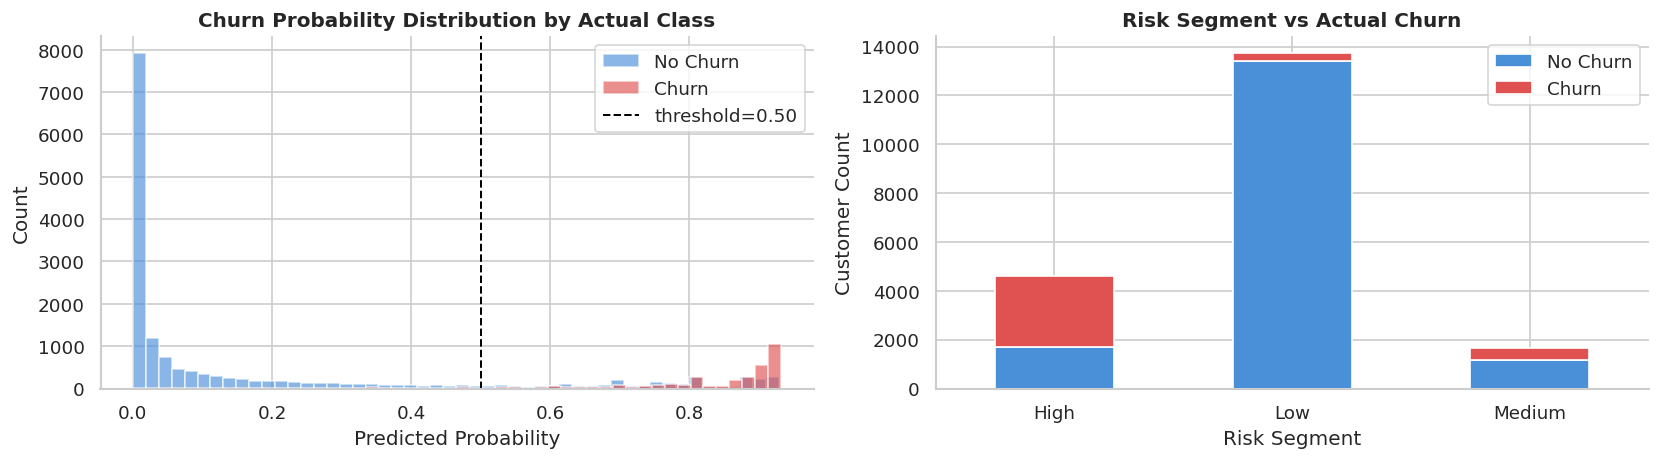

In [ ]:
# Probability distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram by actual class
for label, color, name in [(0, "#4A90D9", "No Churn"), (1, "#E05252", "Churn")]:
    subset = results_df.loc[results_df["actual_churn"] == label, "churn_probability"]
    axes[0].hist(subset, bins=50, alpha=0.65, color=color, label=name, edgecolor="white")
axes[0].axvline(0.5, color="black", ls="--", lw=1.2, label="threshold=0.50")
axes[0].set_title("Churn Probability Distribution by Actual Class", fontweight="bold")
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Count")
axes[0].legend()

# Risk segment stacked bar
seg_counts = results_df.groupby(["risk_segment", "actual_churn"]).size().unstack(fill_value=0)
seg_counts.plot(kind="bar", stacked=True, ax=axes[1],
                color=["#4A90D9", "#E05252"], edgecolor="white")
axes[1].set_title("Risk Segment vs Actual Churn", fontweight="bold")
axes[1].set_xlabel("Risk Segment")
axes[1].set_ylabel("Customer Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["No Churn", "Churn"])

plt.tight_layout()
plt.show()


## 7 · Threshold Tuning

- The default 0.50 threshold is rarely optimal for imbalanced churn datasets.

- We sweep thresholds and choose the one that maximises **F1** (or optionally **Recall**
for aggressive retention campaigns).

In [ ]:
proba_test = results_df["churn_probability"].values

thresholds = np.arange(0.10, 0.91, 0.01)
metrics_rows = []
for t in thresholds:
    preds = (proba_test >= t).astype(int)
    metrics_rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall":    recall_score(y_test, preds,    zero_division=0),
        "f1":        f1_score(y_test, preds,         zero_division=0),
        "accuracy":  accuracy_score(y_test, preds),
    })

thresh_df = pd.DataFrame(metrics_rows)

best_f1_row   = thresh_df.loc[thresh_df["f1"].idxmax()]
best_rec_row  = thresh_df.loc[(thresh_df["recall"] >= 0.80).idxmax()]  # first ≥80% recall

print(f"Best F1 threshold  : {best_f1_row['threshold']:.2f}  "
      f"→  F1={best_f1_row['f1']:.4f}  "
      f"Precision={best_f1_row['precision']:.4f}  "
      f"Recall={best_f1_row['recall']:.4f}")
print(f"80% recall threshold: {best_rec_row['threshold']:.2f}  "
      f"→  F1={best_rec_row['f1']:.4f}  "
      f"Precision={best_rec_row['precision']:.4f}  "
      f"Recall={best_rec_row['recall']:.4f}")

# Use best-F1 threshold for final evaluation
BEST_THRESHOLD = best_f1_row["threshold"]


Best F1 threshold  : 0.70  →  F1=0.6940  Precision=0.6275  Recall=0.7762
80% recall threshold: 0.10  →  F1=0.5731  Precision=0.4046  Recall=0.9818


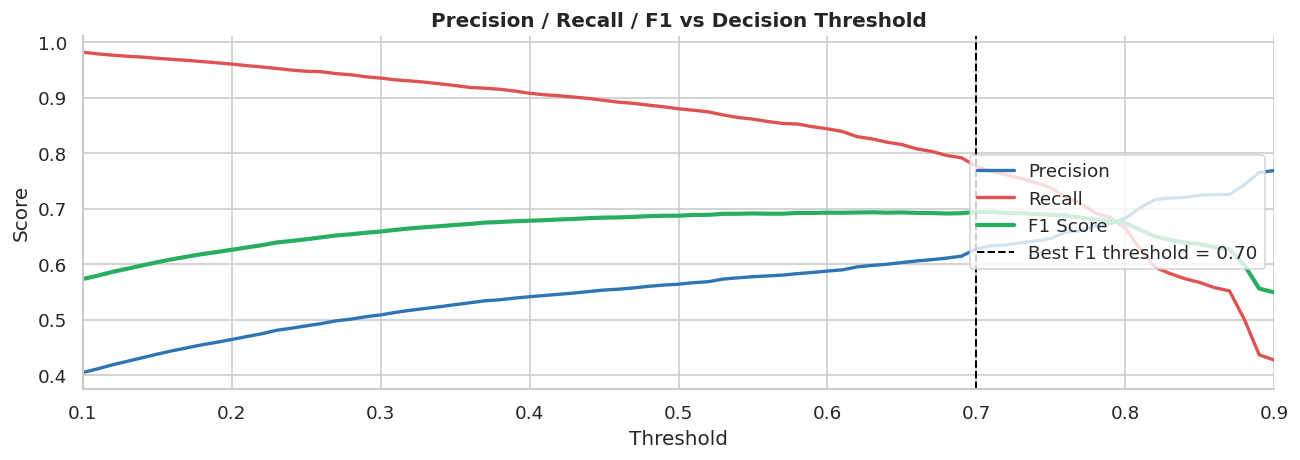

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", color="#2E75B6", lw=2)
ax.plot(thresh_df["threshold"], thresh_df["recall"],    label="Recall",    color="#E05252", lw=2)
ax.plot(thresh_df["threshold"], thresh_df["f1"],        label="F1 Score",  color="#27AE60", lw=2.5)
ax.axvline(BEST_THRESHOLD, color="black", ls="--", lw=1.2,
           label=f"Best F1 threshold = {BEST_THRESHOLD:.2f}")
ax.set_title("Precision / Recall / F1 vs Decision Threshold", fontweight="bold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend(loc="upper left")
ax.set_xlim(0.10, 0.90)
plt.tight_layout()
plt.show()


## 8 · Evaluation Report

All metrics computed on the held-out **test set (20%)** using the best-F1 threshold.

| Metric | Description |
|--------|-------------|
| **Accuracy** | Overall correct predictions |
| **Precision** | Of predicted churners, how many actually churned |
| **Recall** | Of actual churners, how many were caught |
| **F1** | Harmonic mean of precision and recall |
| **ROC-AUC** | Discrimination ability across all thresholds |
| **AP** | Area under precision-recall curve |


In [ ]:
# Final predictions at best threshold
y_pred_final = (proba_test >= BEST_THRESHOLD).astype(int)

acc       = accuracy_score(y_test,  y_pred_final)
prec      = precision_score(y_test, y_pred_final, zero_division=0)
rec       = recall_score(y_test,    y_pred_final, zero_division=0)
f1        = f1_score(y_test,        y_pred_final, zero_division=0)
roc_auc   = roc_auc_score(y_test,   proba_test)
ap        = average_precision_score(y_test, proba_test)

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Avg Precision (AP)"],
    "Value":  [acc, prec, rec, f1, roc_auc, ap],
    "Notes":  [
        "Overall correct",
        "Of predicted churners, true positives",
        "Of actual churners, caught by model",
        "Balance of precision & recall",
        "Threshold-independent discrimination",
        "Area under precision-recall curve",
    ]
}).set_index("Metric")
summary["Value"] = summary["Value"].map("{:.4f}".format)
print(f"\n{'='*52}")
print(f"  EVALUATION REPORT  (threshold = {BEST_THRESHOLD:.2f})")
print(f"{'='*52}")
print(summary.to_string())
print(f"{'='*52}\n")
print(classification_report(y_test, y_pred_final, target_names=["No Churn", "Churn"]))



  EVALUATION REPORT  (threshold = 0.70)
                     Value                                  Notes
Metric                                                           
Accuracy            0.8723                        Overall correct
Precision           0.6275  Of predicted churners, true positives
Recall              0.7762    Of actual churners, caught by model
F1 Score            0.6940          Balance of precision & recall
ROC-AUC             0.9301   Threshold-independent discrimination
Avg Precision (AP)  0.7030      Area under precision-recall curve

              precision    recall  f1-score   support

    No Churn       0.95      0.89      0.92     16269
       Churn       0.63      0.78      0.69      3731

    accuracy                           0.87     20000
   macro avg       0.79      0.84      0.81     20000
weighted avg       0.89      0.87      0.88     20000



## 9 · Visualisations

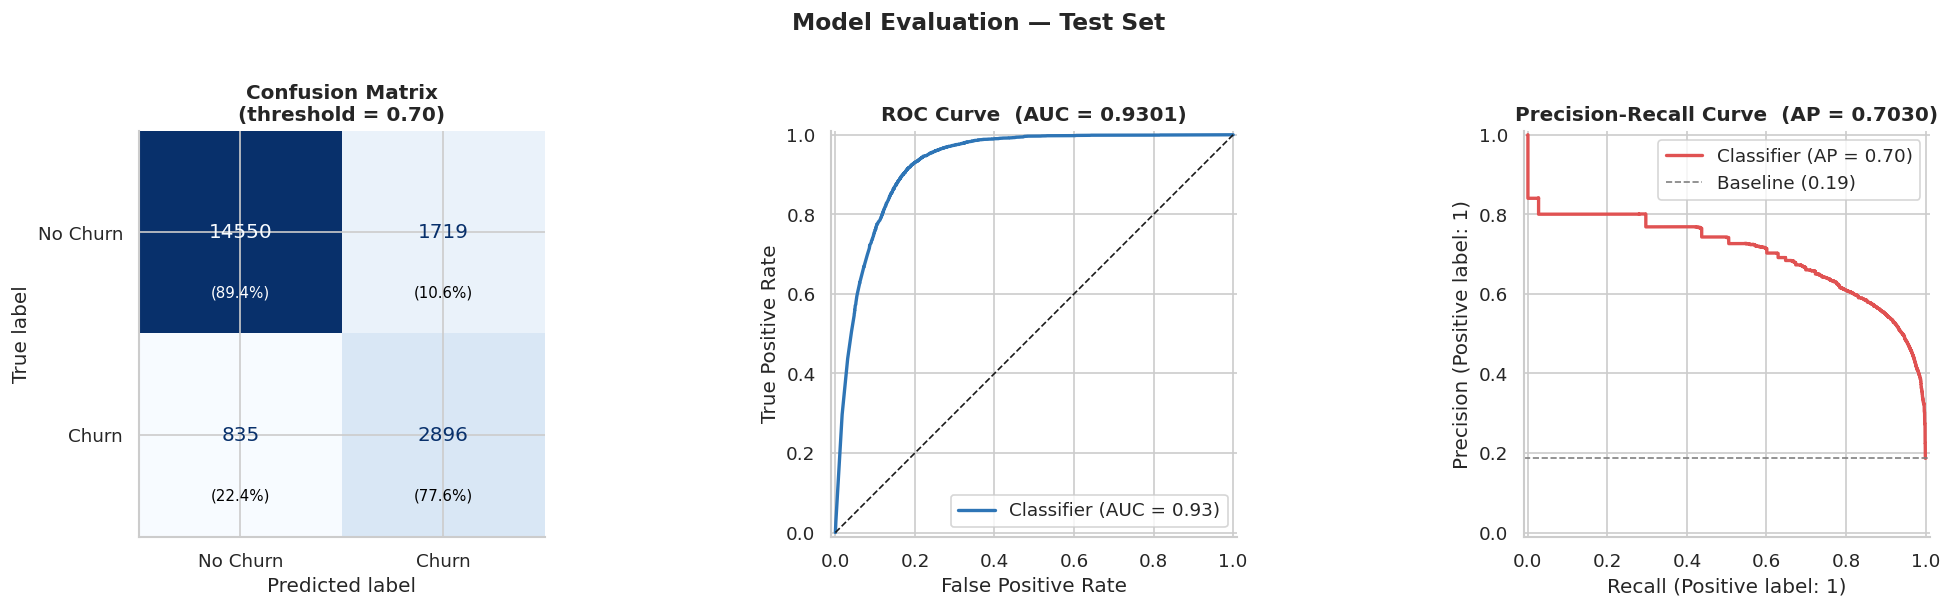


Confusion Matrix Breakdown:
  True  Negatives (correctly predicted no churn) : 14,550
  False Positives (wrongly flagged as churn)     : 1,719
  False Negatives (missed churners)              : 835
  True  Positives (correctly caught churners)    : 2,896


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 9a: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix\n(threshold = {BEST_THRESHOLD:.2f})",
                  fontweight="bold")

# annotate counts + rates
tn, fp, fn, tp = cm.ravel()
for (i, j), val in np.ndenumerate(cm):
    pct = val / cm[i].sum() * 100
    axes[0].text(j, i + 0.3, f"({pct:.1f}%)", ha="center", va="center",
                 fontsize=9, color="white" if (i==j and val > cm.max()*0.4) else "black")

# 9b: ROC Curve
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1],
                                  color="#2E75B6", lw=2)
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_title(f"ROC Curve  (AUC = {roc_auc:.4f})", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

# 9c: Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[2],
                                         color="#E05252", lw=2)
axes[2].axhline(y_test.mean(), color="gray", ls="--", lw=1,
                label=f"Baseline ({y_test.mean():.2f})")
axes[2].set_title(f"Precision-Recall Curve  (AP = {ap:.4f})", fontweight="bold")
axes[2].legend(loc="upper right")

plt.suptitle("Model Evaluation — Test Set", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True  Negatives (correctly predicted no churn) : {tn:,}")
print(f"  False Positives (wrongly flagged as churn)     : {fp:,}")
print(f"  False Negatives (missed churners)              : {fn:,}")
print(f"  True  Positives (correctly caught churners)    : {tp:,}")


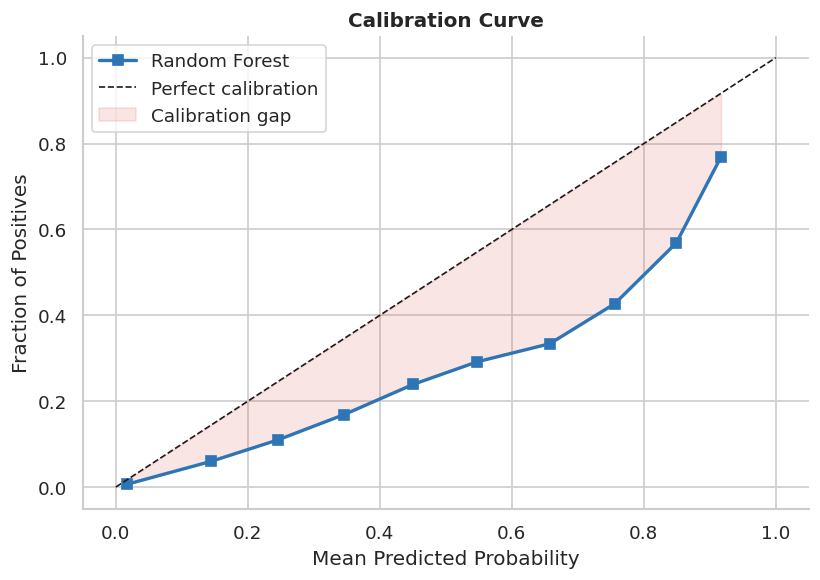

In [ ]:
# 9d: Calibration check

prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prob_pred, prob_true, "s-", color="#2E75B6", lw=2, label="Random Forest")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.fill_between(prob_pred, prob_true, prob_pred,
                alpha=0.15, color="#E05252", label="Calibration gap")
ax.set_title("Calibration Curve", fontweight="bold")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend()
plt.tight_layout()
plt.show()


## 10 · Feature Importance

Two views:
1. **Mean Decrease in Impurity (MDI)** — fast, built into Random Forest
2. **Permutation Importance** — slower but unbiased for correlated features


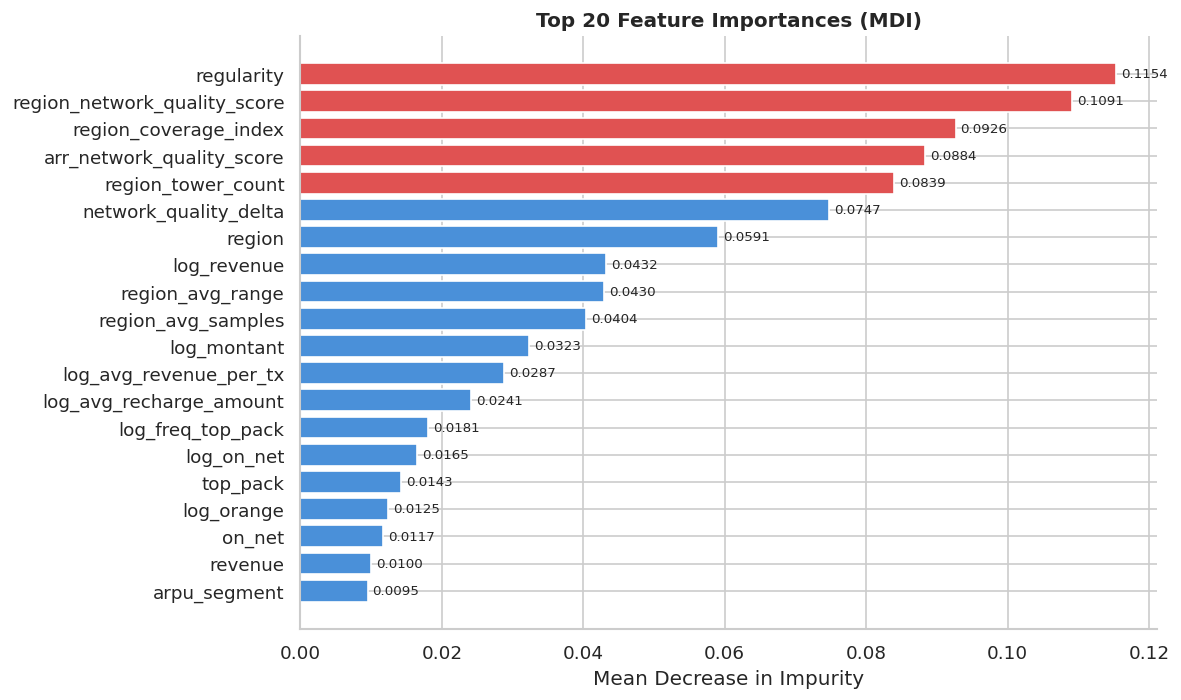


Top 10 features by MDI importance:
regularity                     0.1154
region_network_quality_score   0.1091
region_coverage_index          0.0926
arr_network_quality_score      0.0884
region_tower_count             0.0839
network_quality_delta          0.0747
region                         0.0591
log_revenue                    0.0432
region_avg_range               0.0430
region_avg_samples             0.0404


In [ ]:
# 10a: MDI importance
importances = pd.Series(rf_model.feature_importances_, index=NUM_COLS)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E05252" if i < 5 else "#4A90D9" for i in range(len(top20))]
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor="white")
ax.set_title("Top 20 Feature Importances (MDI)", fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 10 features by MDI importance:")
print(top20.head(10).to_string())


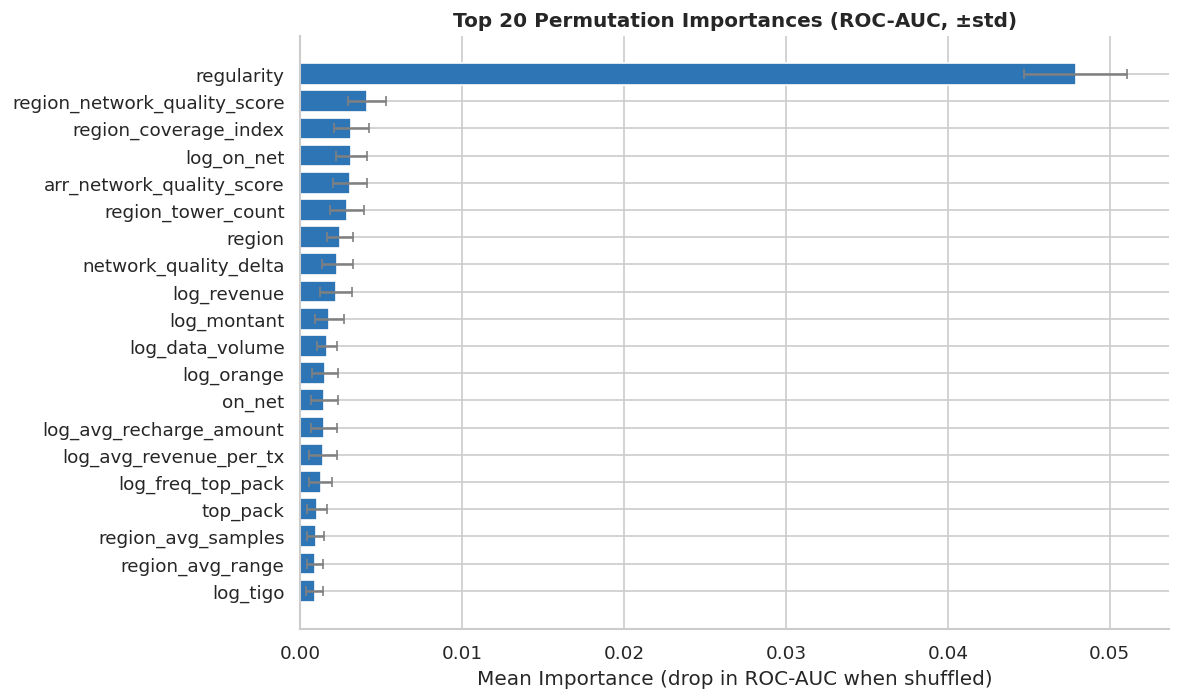

In [ ]:
# 10b: Permutation importance (on a 5k sample for speed)

sample_idx = np.random.choice(len(X_test_imp), size=min(5000, len(X_test_imp)), replace=False)
X_sample   = X_test_imp.iloc[sample_idx]
y_sample   = y_test.iloc[sample_idx]

perm = permutation_importance(
    rf_model, X_sample, y_sample,
    n_repeats=10, random_state=SEED, n_jobs=-1, scoring="roc_auc"
)
perm_df = pd.DataFrame({
    "feature":   NUM_COLS,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std,
}).sort_values("importance_mean", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df["feature"][::-1], perm_df["importance_mean"][::-1],
        xerr=perm_df["importance_std"][::-1],
        color="#2E75B6", edgecolor="white", capsize=3, ecolor="gray")
ax.set_title("Top 20 Permutation Importances (ROC-AUC, ±std)", fontweight="bold")
ax.set_xlabel("Mean Importance (drop in ROC-AUC when shuffled)")
plt.tight_layout()
plt.show()


In [ ]:
# ── 10c: Compare MDI vs Permutation ──────────────────────────────────────────
mdi_top10  = set(importances.sort_values(ascending=False).head(10).index)
perm_top10 = set(perm_df.head(10)["feature"])

both   = mdi_top10 & perm_top10
mdi_only  = mdi_top10 - perm_top10
perm_only = perm_top10 - mdi_top10

print("Features in TOP-10 by BOTH methods (most reliable):")
for f in sorted(both): print(f"{f}")
print("\nTop-10 MDI only (may be inflated due to high cardinality):")
for f in sorted(mdi_only): print(f"{f}")
print("\nTop-10 Permutation only:")
for f in sorted(perm_only): print(f"{f}")


Features in TOP-10 by BOTH methods (most reliable):
arr_network_quality_score
log_revenue
network_quality_delta
region
region_coverage_index
region_network_quality_score
region_tower_count
regularity

Top-10 MDI only (may be inflated due to high cardinality):
region_avg_range
region_avg_samples

Top-10 Permutation only:
log_montant
log_on_net


## 11 · Export Results

Outputs saved:
- `churn_predictions.csv` — full scored test set  
- `evaluation_metrics.csv` — metric summary  
- `feature_importances.csv` — ranked feature importances  
- `rf_churn_model.joblib` — serialised model

In [ ]:
# Build full scored dataframe
scored = X_test_imp.copy()
scored["actual_churn"]       = y_test.values
scored["churn_probability"]  = proba_test
scored["churn_prediction"]   = y_pred_final
scored["risk_segment"]       = results_df["risk_segment"].values
scored = scored.sort_values("churn_probability", ascending=False)

scored.to_csv(churn_predictions_file, index=False)
print(f"churn_predictions.csv  ({len(scored):,} rows)")

churn_predictions.csv  (20,000 rows)


In [ ]:
# Metrics
metrics_out = pd.DataFrame({
    "metric":    ["accuracy", "precision", "recall", "f1", "roc_auc", "avg_precision", "threshold"],
    "value":     [acc, prec, rec, f1, roc_auc, ap, BEST_THRESHOLD],
})
metrics_out.to_csv(evaluation_metrics_file, index=False)
print("evaluation_metrics.csv")

evaluation_metrics.csv


In [ ]:
# Feature importances
fi_out = importances.sort_values(ascending=False).reset_index()
fi_out.columns = ["feature", "mdi_importance"]
fi_out.to_csv(feature_importances_file, index=False)
print("feature_importances.csv")

In [ ]:
print("\nTop 5 highest-risk customers in test set:")
display(scored.head(5)[["churn_probability", "risk_segment", "actual_churn",
                          "regularity" if "regularity" in scored.columns else scored.columns[0]]])

feature_importances.csv

Top 5 highest-risk customers in test set:


,churn_probability,risk_segment,actual_churn,regularity
6131,0.9320,High,1,1.0000
1463,0.9289,High,1,1.0000
5170,0.9289,High,0,1.0000
1811,0.9289,High,0,1.0000
19110,0.9289,High,1,1.0000


### References
- [scikit-learn docs](https://scikit-learn.org/stable/)  
  - [sklearn RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
  - [sklearn Ensemble Methods](https://scikit-learn.org/stable/modules/ensemble.html)  
  - [sklearn.metrics.f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
  - [sklearn Metrics & Scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
  - [sklearn Feature Importance](https://scikit-learn.org/stable/modules/ensemble.html#feature-importances)
  - [imbalanced-learn SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)  
  - [SHAP for tree models](https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/tree_based_models/Census+income+classification+with+XGBoost.html)

- [pandas docs](https://pandas.pydata.org/docs/)  
- [seaborn docs](https://seaborn.pydata.org/)